# Laboratorio 2
- Jerónimo Vásquez Ponce - 202223824
- Jacobo Zarruk Estrada - 202223913

## Importación librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, PolynomialFeatures, FunctionTransformer
from sklearn.impute import SimpleImputer
from scipy.stats import shapiro
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Extracción de los datos transformados del laboratorio 1

In [2]:
df = pd.read_csv("Datos Lab 1.csv")
df = df.drop_duplicates()
columnas = ['CVD Risk Score', 'Total Cholesterol (mg/dL)', 'Estimated LDL (mg/dL)']
df = df[(df[columnas] >= 0).all(axis=1)]
df = df[df['CVD Risk Score'] <= 30]
df = df.drop(columns=['Height (cm)', 'Patient ID', 'Date of Service', 'CVD Risk Level', 'Blood Pressure (mmHg)'])
df = df.dropna(subset=['CVD Risk Score'])

X = df.drop(columns=['CVD Risk Score'])
y = df['CVD Risk Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [3]:
X_train.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL)
1480,M,40.0,64.800,1.760,20.900,109.100,294.0,70.0,89.0,N,Y,High,N,0.620,135.0,96.0,Hypertension Stage 1,194.0
910,F,26.0,85.659,1.803,32.454,107.746,213.0,66.0,133.0,N,Y,Low,Y,0.598,156.0,118.0,Hypertension Stage 2,117.0
902,F,32.0,54.200,1.850,15.800,89.800,223.0,78.0,71.0,N,Y,Moderate,N,0.485,94.0,78.0,Normal,115.0
491,F,33.0,105.351,1.680,28.038,109.807,288.0,48.0,161.0,Y,Y,High,Y,0.654,146.0,91.0,Hypertension Stage 2,210.0
467,M,30.0,105.300,1.620,40.100,88.200,162.0,43.0,79.0,Y,N,High,N,0.544,121.0,NaN,Hypertension Stage 2,89.0


In [4]:
X_test.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL)
1579,M,40.0,21.316,1.900,24.300,NaN,216.0,61.0,146.0,N,N,High,N,0.380,90.0,72.0,Normal,125.0
882,M,48.0,107.611,1.718,26.407,80.589,162.0,69.0,94.0,Y,N,Low,N,0.469,117.0,60.0,Normal,63.0
759,M,47.0,71.900,1.860,20.800,88.600,211.0,45.0,106.0,Y,Y,Moderate,Y,0.476,121.0,92.0,Hypertension Stage 2,136.0
1112,F,35.0,64.200,1.870,18.400,100.800,193.0,49.0,134.0,Y,Y,Moderate,N,0.539,NaN,67.0,Hypertension Stage 1,114.0
1525,F,60.0,54.100,1.860,15.600,74.100,299.0,32.0,120.0,N,Y,High,Y,0.398,125.0,61.0,Elevated,237.0


In [5]:
y_train.head()

1480    18.810
910     20.551
902     14.320
491     20.668
467     17.310
Name: CVD Risk Score, dtype: float64

In [6]:
y_test.head()

1579    13.680
882     14.371
759     16.430
1112    16.240
1525    17.350
Name: CVD Risk Score, dtype: float64

In [7]:
def identificar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    mask_outliers = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    indices_outliers = df[mask_outliers].index.tolist()
    outliers_df = df.loc[indices_outliers]
    limites = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'limite_inferior': limite_inferior, 'limite_superior': limite_superior}
    return indices_outliers, outliers_df, limites

def capping_outliers(X):
    X_copy = X.copy()
    for columna in X_copy.select_dtypes(include='number').columns:
        indices, outliers, limites = identificar_outliers(X_copy, columna)
        X_copy.loc[X_copy[columna] < limites['limite_inferior'], columna] = limites['limite_inferior']
        X_copy.loc[X_copy[columna] > limites['limite_superior'], columna] = limites['limite_superior']
    return X_copy

capping_outliers_tr = FunctionTransformer(capping_outliers)

num_cols = ['BMI', 'Total Cholesterol (mg/dL)', 'Systolic BP', 'Estimated LDL (mg/dL)', 'Weight (kg)']
cat_cols = ['Diabetes Status', 'Blood Pressure Category']

## Pipelines

In [8]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()) 
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

### Pipeline Polinomial

Se construye un pipeline de regresión polinomial que extiende el modelo lineal del Lab 1 generando combinaciones polinomiales de las variables numéricas (por ejemplo BMI², BMI×Cholesterol, etc.). Esto permite capturar relaciones no lineales entre las variables predictoras y el CVD Risk Score que un modelo lineal simple no puede detectar.

La búsqueda de hiperparámetros se realiza mediante GridSearchCV con validación cruzada de 5 folds, explorando:
- Grado del polinomio (2, 3, 4): para evaluar cómo aumenta el desempeño con la complejidad y detectar el punto de sobreajuste.
- Tipo de escalador (MinMaxScaler, StandardScaler): porque PolynomialFeatures genera valores muy grandes al elevar las variables al cuadrado o al cubo, por lo que el escalado es crítico para la estabilidad numérica.

Se aplica PolynomialFeatures únicamente sobre las variables numéricas ya transformadas, para evitar generar interacciones sin sentido con las variables categóricas codificadas.

In [9]:
pipeline_poly = Pipeline(steps=[
    ('capping_outliers', capping_outliers_tr),
    ('preprocesamiento', preprocessor),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('modelo', LinearRegression())
])

pipeline_poly

,steps,"[('capping_outliers', ...), ('preprocesamiento', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cap...0026A8786CAF0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


### Pipeline Ridge

Se construye un pipeline de regresión Ridge que incorpora regularización L2. Esta penaliza la magnitud de los coeficientes, lo que ayuda a controlar la multicolinealidad detectada en el Lab 1 (VIF de hasta 43 en Total Cholesterol). A diferencia de la regresión lineal estándar, Ridge reduce los coeficientes hacia cero sin eliminarlos, lo que estabiliza las estimaciones sin perder variables.

La búsqueda de hiperparámetros explorará:
- Alpha (0.01, 0.1, 1, 10, 100): controla la intensidad de la penalización. Valores más altos penalizan más los coeficientes grandes.
- Tipo de escalador (MinMaxScaler, StandardScaler): el escalado es fundamental en modelos regularizados porque la penalización depende de la magnitud de los coeficientes, y variables en escalas diferentes serían penalizadas de forma desigual.

In [10]:
pipeline_ridge = Pipeline(steps=[
    ('capping_outliers', capping_outliers_tr),
    ('preprocesamiento', preprocessor),
    ('modelo', Ridge())
])

pipeline_ridge

,steps,"[('capping_outliers', ...), ('preprocesamiento', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cap...0026A8786CAF0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


### Pipeline Lasso

Se construye un pipeline de regresión Lasso que incorpora regularización L1. A diferencia de Ridge, Lasso puede llevar coeficientes exactamente a cero, lo que funciona como selección automática de variables. Esto permitirá identificar cuáles de las variables seleccionadas en el Lab 1 son realmente necesarias para predecir el riesgo cardiovascular y cuáles son redundantes.

La búsqueda de hiperparámetros explorará:
- Alpha (0.01, 0.1, 1, 10, 100): controla la intensidad de la penalización. Valores más altos fuerzan más coeficientes a cero.
- Tipo de escalador (MinMaxScaler, StandardScaler): igual que en Ridge, el escalado es fundamental para que la penalización sea equitativa entre variables.

In [11]:
pipeline_lasso = Pipeline(steps=[
    ('capping_outliers', capping_outliers_tr),
    ('preprocesamiento', preprocessor),
    ('modelo', Lasso(max_iter=10000))
])

pipeline_lasso

,steps,"[('capping_outliers', ...), ('preprocesamiento', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cap...0026A8786CAF0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


### Pipeline Polinomial regularizado

Se construye un pipeline que combina la generación de características polinomiales con regularización Ridge. Este modelo busca capturar relaciones no lineales entre las variables y el riesgo cardiovascular, mientras que la regularización controla el sobreajuste que naturalmente ocurre al aumentar la complejidad polinomial. Es el modelo más complejo del laboratorio.

La búsqueda de hiperparámetros explorará:
- Grado del polinomio (2, 3): complejidad de las interacciones.
- Alpha de regularización (0.01, 0.1, 1, 10, 100): intensidad de la penalización.
- Tipo de escalador (MinMaxScaler, StandardScaler): para estabilidad numérica.

In [12]:
pipeline_poly_reg = Pipeline(steps=[
    ('capping_outliers', capping_outliers_tr),
    ('preprocesamiento', preprocessor),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('modelo', Ridge())
])

pipeline_poly_reg

,steps,"[('capping_outliers', ...), ('preprocesamiento', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cap...0026A8786CAF0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [13]:
pipeline_poly_reg_lasso = Pipeline(steps=[
    ('capping_outliers', capping_outliers_tr),
    ('preprocesamiento', preprocessor),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('modelo', Lasso())
])

pipeline_poly_reg_lasso

,steps,"[('capping_outliers', ...), ('preprocesamiento', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cap...0026A8786CAF0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


## Modelo de regresión polinomial

In [14]:
param_grid_poly = {
    'poly__degree': [2, 3, 4],
    'preprocesamiento__num__scaler': [MinMaxScaler(), StandardScaler()]
}

grid_poly = GridSearchCV(
    pipeline_poly,
    param_grid_poly,
    cv=5,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1
)

grid_poly.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'poly__degree': [2, 3, ...], 'preprocesamiento__num__scaler': [MinMaxScaler(), StandardScaler()]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,func,<function cap...0026A8786CAF0>


### Mejores hiperparametros

In [15]:
print("Mejores hiperparametros: ", grid_poly.best_params_)
print(f"Mejor R^2 promedio:  {grid_poly.best_score_}")

rta_poly = pd.DataFrame(grid_poly.cv_results_)


Mejores hiperparametros:  {'poly__degree': 2, 'preprocesamiento__num__scaler': StandardScaler()}
Mejor R^2 promedio:  0.43933469316768053


### Evaluación del modelo

In [16]:
best_poly = grid_poly.best_estimator_

y_train_pred_poly = best_poly.predict(X_train)
y_test_pred_poly = best_poly.predict(X_test)

print("Train")
print(f"R²: {r2_score(y_train, y_train_pred_poly)}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_poly)}")
print(f"RMSE: {root_mean_squared_error(y_train, y_train_pred_poly)}")

print("Test")
print(f"R²: {r2_score(y_test, y_test_pred_poly)}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_poly)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_poly)}")

Train
R²: 0.5728388843276391
MAE: 0.8141023178596845
RMSE: 1.9686548005996056
Test
R²: 0.5124722580552581
MAE: 0.8808712933527273
RMSE: 2.2035585252631376


### Scatter plot para ver que tan bien se esta comportando el modelo

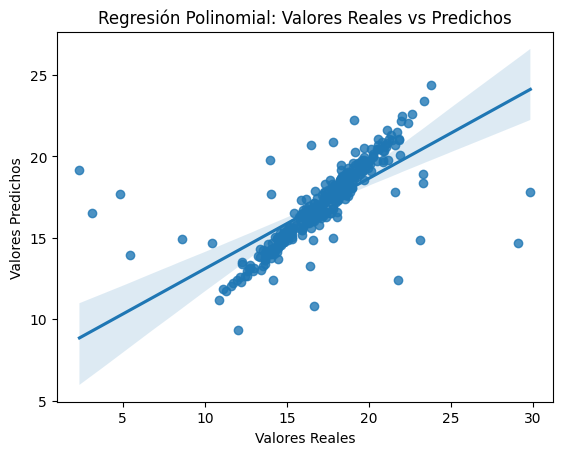

In [17]:
sns.regplot(x=y_test, y=y_test_pred_poly)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Regresión Polinomial: Valores Reales vs Predichos')
plt.show()

## Curvas de validación

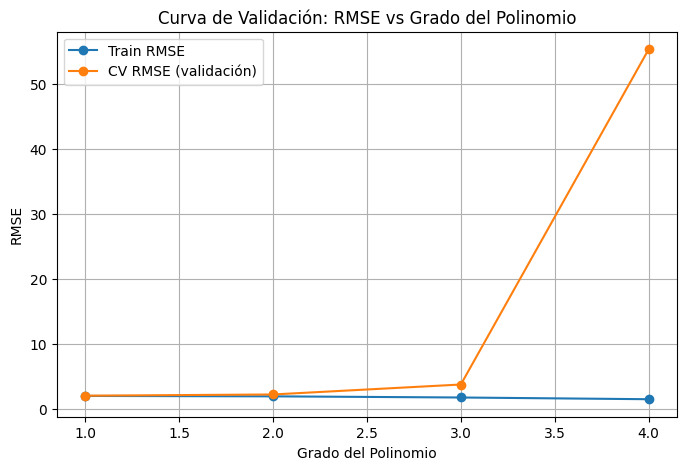

In [61]:
from sklearn.model_selection import validation_curve

grados = np.array([1, 2, 3, 4])

train_scores, test_scores = validation_curve(pipeline_poly,X_train, y_train,param_name='poly__degree',param_range=grados,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1)


train_rmse = -train_scores
test_rmse = -test_scores

train_rmse_mean = train_rmse.mean(axis=1)
train_rmse_std = train_rmse.std(axis=1)
test_rmse_mean = test_rmse.mean(axis=1)
test_rmse_std = test_rmse.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(grados, train_rmse_mean, 'o-', label='Train RMSE')
plt.plot(grados, test_rmse_mean, 'o-', label='CV RMSE (validación)')
plt.xlabel('Grado del Polinomio')
plt.ylabel('RMSE')
plt.title('Curva de Validación: RMSE vs Grado del Polinomio')
plt.legend()
plt.grid(True)
plt.show()


## Modelos de regresión lineal regularizados

### Ridge

In [19]:
param_grid_ridge = {
    'modelo__alpha': [0.01, 0.1, 1, 10, 100],
    'preprocesamiento__num__scaler': [MinMaxScaler(), StandardScaler()]
}

grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=5, scoring='r2', return_train_score=True, n_jobs=-1)
grid_ridge.fit(X_train, y_train)

,estimator,"Pipeline(step...o', Ridge())])"
,param_grid,"{'modelo__alpha': [0.01, 0.1, ...], 'preprocesamiento__num__scaler': [MinMaxScaler(), StandardScaler()]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,func,<function cap...0026A8786CAF0>


In [20]:
best_ridge = grid_ridge.best_estimator_

y_train_pred_ridge = best_ridge.predict(X_train)
y_test_pred_ridge = best_ridge.predict(X_test)

print("Train")
print(f"R²: {r2_score(y_train, y_train_pred_ridge)}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_ridge)}")
print(f"RMSE: {root_mean_squared_error(y_train, y_train_pred_ridge)}")

print("Test")
print(f"R²: {r2_score(y_test, y_test_pred_ridge)}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_ridge)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_ridge)}")

Train
R²: 0.5509307563280865
MAE: 0.8001868328470406
RMSE: 2.0185075118299998
Test
R²: 0.5348935606481731
MAE: 0.7990198104939177
RMSE: 2.1522915419582738


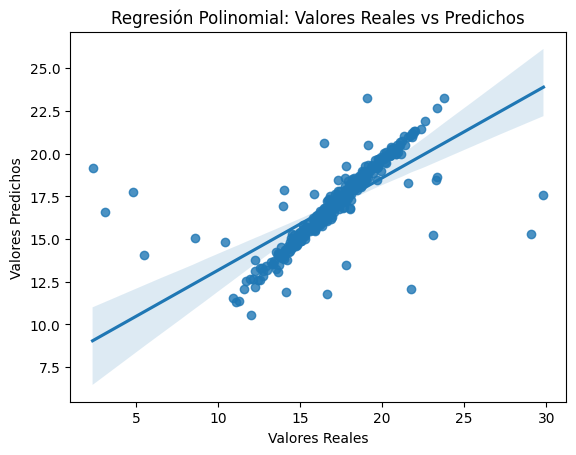

In [64]:
sns.regplot(x=y_test, y=y_test_pred_ridge)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Regresión Polinomial: Valores Reales vs Predichos')
plt.show()

### Lasso

In [22]:
param_grid_lasso = {
    'modelo__alpha': [0.01, 0.1, 1, 10, 100],
    'preprocesamiento__num__scaler': [MinMaxScaler(), StandardScaler()]
}

grid_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, cv=5, scoring='r2', return_train_score=True, n_jobs=-1)
grid_lasso.fit(X_train, y_train)

,estimator,Pipeline(step...iter=10000))])
,param_grid,"{'modelo__alpha': [0.01, 0.1, ...], 'preprocesamiento__num__scaler': [MinMaxScaler(), StandardScaler()]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,func,<function cap...0026A8786CAF0>


In [23]:
best_lasso = grid_lasso.best_estimator_

y_train_pred_lasso = best_lasso.predict(X_train)
y_test_pred_lasso = best_lasso.predict(X_test)

print("Train")
print(f"R²: {r2_score(y_train, y_train_pred_lasso)}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_lasso)}")
print(f"RMSE: {root_mean_squared_error(y_train, y_train_pred_lasso)}")

print("Test")
print(f"R²: {r2_score(y_test, y_test_pred_lasso)}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_lasso)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_lasso)}")

Train
R²: 0.5503060780877163
MAE: 0.8101967973434497
RMSE: 2.019910947428097
Test
R²: 0.5312480034369123
MAE: 0.809467315824389
RMSE: 2.1607100309310567


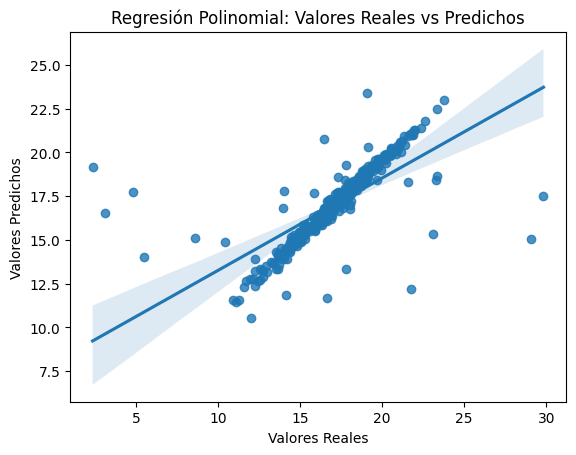

In [24]:
sns.regplot(x=y_test, y=y_test_pred_lasso)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Regresión Polinomial: Valores Reales vs Predichos')
plt.show()

## Modelo de regresión polinomial regularizado

### Ridge

In [25]:
param_grid_poly_reg = {
    'poly__degree': [2, 3],
    'modelo__alpha': [0.01, 0.1, 1, 10, 100],
    'preprocesamiento__num__scaler': [MinMaxScaler(), StandardScaler()]
}

grid_poly_reg = GridSearchCV(pipeline_poly_reg, param_grid_poly_reg, cv=5, scoring='r2', return_train_score=True, n_jobs=-1)
grid_poly_reg.fit(X_train, y_train)

,estimator,"Pipeline(step...o', Ridge())])"
,param_grid,"{'modelo__alpha': [0.01, 0.1, ...], 'poly__degree': [2, 3], 'preprocesamiento__num__scaler': [MinMaxScaler(), StandardScaler()]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,func,<function cap...0026A8786CAF0>


In [26]:
best_poly_reg = grid_poly_reg.best_estimator_

y_train_pred_poly_reg = best_poly_reg.predict(X_train)
y_test_pred_poly_reg = best_poly_reg.predict(X_test)

print("Train")
print(f"R²: {r2_score(y_train, y_train_pred_poly_reg)}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_poly_reg)}")
print(f"RMSE: {root_mean_squared_error(y_train, y_train_pred_poly_reg)}")

print("Test")
print(f"R²: {r2_score(y_test, y_test_pred_poly_reg)}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_poly_reg)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_poly_reg)}")

Train
R²: 0.5505447198047564
MAE: 0.8581836084251575
RMSE: 2.0193749172958957
Test
R²: 0.537122312736986
MAE: 0.8708238898603985
RMSE: 2.147128546683493


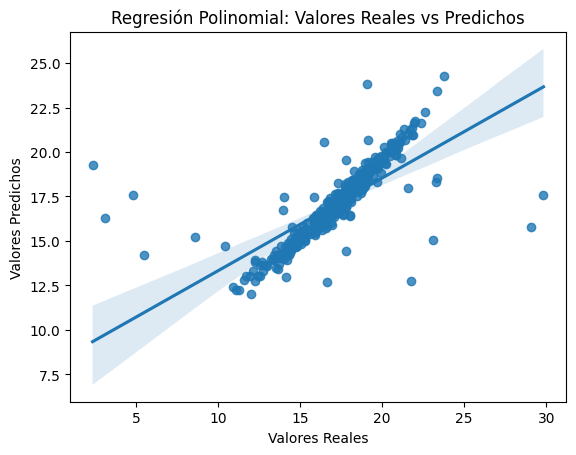

In [27]:
sns.regplot(x=y_test, y=y_test_pred_poly_reg)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Regresión Polinomial: Valores Reales vs Predichos')
plt.show()

### Lasso

In [28]:
param_grid_poly_reg_lasso = {
    'poly__degree': [2, 3],
    'modelo__alpha': [0.01, 0.1, 1, 10, 100],
    'preprocesamiento__num__scaler': [MinMaxScaler(), StandardScaler()]
}

grid_poly_reg_lasso = GridSearchCV(pipeline_poly_reg_lasso, param_grid_poly_reg_lasso, cv=5, scoring='r2', return_train_score=True, n_jobs=-1)
grid_poly_reg_lasso.fit(X_train, y_train)

,estimator,"Pipeline(step...o', Lasso())])"
,param_grid,"{'modelo__alpha': [0.01, 0.1, ...], 'poly__degree': [2, 3], 'preprocesamiento__num__scaler': [MinMaxScaler(), StandardScaler()]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,func,<function cap...0026A8786CAF0>


In [29]:
best_poly_reg_lasso = grid_poly_reg.best_estimator_

y_train_pred_poly_reg_lasso = best_poly_reg_lasso.predict(X_train)
y_test_pred_poly_reg_lasso = best_poly_reg_lasso.predict(X_test)

print("Train")
print(f"R²: {r2_score(y_train, y_train_pred_poly_reg_lasso)}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_poly_reg_lasso)}")
print(f"RMSE: {root_mean_squared_error(y_train, y_train_pred_poly_reg_lasso)}")

print("Test")
print(f"R²: {r2_score(y_test, y_test_pred_poly_reg_lasso)}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_poly_reg_lasso)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_poly_reg_lasso)}")

Train
R²: 0.5505447198047564
MAE: 0.8581836084251575
RMSE: 2.0193749172958957
Test
R²: 0.537122312736986
MAE: 0.8708238898603985
RMSE: 2.147128546683493


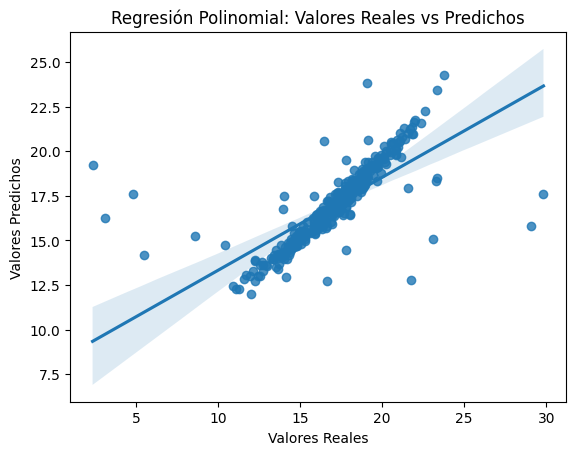

In [30]:
sns.regplot(x=y_test, y=y_test_pred_poly_reg_lasso)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Regresión Polinomial: Valores Reales vs Predichos')
plt.show()

## Cross Validation

In [31]:
print("Cross Validation:")

print(f"Polinomial: {grid_poly.best_score_}")
print(f"Ridge: {grid_ridge.best_score_}")
print(f"Lasso: {grid_lasso.best_score_}")
print(f"Poly+Ridge: {grid_poly_reg.best_score_}")
print(f"Poly+Lasso: {grid_poly_reg_lasso.best_score_}")

Cross Validation:
Polinomial: 0.43933469316768053
Ridge: 0.5359543750313696
Lasso: 0.5398695841053192
Poly+Ridge: 0.5290037877335474
Poly+Lasso: 0.5331005197664392


## General modelos

In [65]:
feature_names = best_lasso.named_steps['preprocesamiento'].get_feature_names_out()
coeficientes = best_lasso.named_steps['modelo'].coef_

lasso_vars = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coeficientes
})

print("Variables que estan:")
print(lasso_vars[lasso_vars['Coeficiente'] != 0])
print()
print("Variables que no estan")
print(lasso_vars[lasso_vars['Coeficiente'] == 0])

Variables que estan:
                                            Variable  Coeficiente
0                                           num__BMI     7.221708
1                     num__Total Cholesterol (mg/dL)     6.074532
2                                   num__Systolic BP     5.032892
4                                   num__Weight (kg)     0.786458
5                             cat__Diabetes Status_Y     1.999843
7  cat__Blood Pressure Category_Hypertension Stage 2     0.211347
8                cat__Blood Pressure Category_Normal    -0.460056

Variables que no estan
                                            Variable  Coeficiente
3                         num__Estimated LDL (mg/dL)          0.0
6  cat__Blood Pressure Category_Hypertension Stage 1         -0.0


In [52]:
coeficientes = best_ridge.steps[-1][1].coef_
nombres_columnas = best_ridge.named_steps['preprocesamiento'].get_feature_names_out()
intercepto = best_ridge.named_steps['modelo'].intercept_

print(coeficientes)
print(nombres_columnas)
print(intercepto)

[ 7.04195007  5.80227394  5.17450506  0.38074902  1.2886759   2.01907622
 -0.14964102  0.10729894 -0.59702522]
['num__BMI' 'num__Total Cholesterol (mg/dL)' 'num__Systolic BP'
 'num__Estimated LDL (mg/dL)' 'num__Weight (kg)' 'cat__Diabetes Status_Y'
 'cat__Blood Pressure Category_Hypertension Stage 1'
 'cat__Blood Pressure Category_Hypertension Stage 2'
 'cat__Blood Pressure Category_Normal']
6.111775530587186


## Comparación y selección del mejor modelo

### Tabla Comparativa de Modelos

| Métrica | Polinomial (Train) | Polinomial (Test) | Ridge (Train) | Ridge (Test) | Lasso (Train) | Lasso (Test) | Poly+Ridge (Train) | Poly+Ridge (Test) | Poly+Lasso (Train) | Poly+Lasso (Test) |
|:--------|:------------------:|:-----------------:|:-------------:|:------------:|:-------------:|:------------:|:-------------------:|:-----------------:|:-------------------:|:-----------------:|
| R²      | 0.5728             | 0.5125            | 0.5509        | 0.5349       | 0.5503        | 0.5312       | 0.5505              | 0.5371            | 0.5505              | 0.5371            |
| MAE     | 0.8141             | 0.8809            | 0.8002        | 0.7990       | 0.8102        | 0.8095       | 0.8582              | 0.8708            | 0.8582              | 0.8708            |
| RMSE    | 1.9687             | 2.2036            | 2.0185        | 2.1523       | 2.0199        | 2.1607       | 2.0194              | 2.1471            | 2.0194              | 2.1471            |

### Análisis de resultados

El modelo de regresión polinomial sin regularización obtiene el R² más alto en train (0.5728) pero el más bajo en test (0.5125), con una diferencia de 0.06 entre ambos. Esto puede indicar sobreajuste: el modelo se ajusta bien a los datos de entrenamiento pero generaliza peor a datos nuevos o de testeo. Su MAE en test (0.88) es también el más alto, confirmando que la complejidad polinomial sin control genera predicciones menos precisas fuera del entrenamiento y que se presenta sobreajuste.

Los modelos regularizados (Ridge, Lasso, Polinomial+Ridge y Polinomial+Lasso) presentan métricas de train más modestas pero mucho más cercanas a las de test, lo que indica mejor capacidad de generalización y ausencia de sobreajuste. La diferencia entre train y test en estos modelos es de apenas 0.01-0.02 en R².

Ridge y Lasso simples tienen un desempeño muy similar entre sí. Ridge obtiene un MAE de 0.80 tanto en train como en test, lo que indica estabilidad y consistencia en las predicciones. Lasso obtiene un MAE ligeramente superior (0.81) pero tiene la ventaja de realizar selección automática de variables.

Los modelos Polinomial+Ridge y Polinomial+Lasso obtienen resultados idénticos en todas las métricas (R² 0.5371, MAE 0.87, RMSE 2.15 en test). Esto sugiere que cuando se combinan con características polinomiales, la regularización L1 y L2 convergen a una solución equivalente, probablemente porque el GridSearchCV seleccionó hiperparámetros donde ambas penalizaciones tienen un efecto similar. Aunque logran el mejor R² en test entre todos los modelos, su MAE es mayor que el de Ridge y Lasso simples.

### Selección del mejor modelo

Se selecciona Ridge como el mejor modelo por las siguientes razones:

1. Mejor MAE en test (0.7990): en promedio se equivoca menos de 0.80 puntos, el error más bajo de todos los modelos.
2. Estabilidad: la diferencia entre train y test es mínima (R² 0.5509 vs 0.5349), confirmando ausencia de sobreajuste.
3. Simplicidad: no requiere generación de características polinomiales.
4. Manejo de multicolinealidad: la regularización L2 estabiliza los coeficientes que en el Lab 1 eran inestables por los VIF altos.

Aunque Polinomial+Ridge y Polinomial+Lasso tienen un R² ligeramente mayor en test (0.5371 vs 0.5349), la diferencia es marginal (0.002) y Ridge ofrece menor error promedio y menor complejidad.

## Intervalos de confianza.

In [32]:
from sklearn.utils import resample

n_bootstraps = 500
r2_scores = []
mae_scores = []
rmse_scores = []

best_ridge = grid_ridge.best_estimator_

for i in range(n_bootstraps):
    X_test_boot, y_test_boot = resample(X_test, y_test, random_state=i)
    y_pred_boot = best_ridge.predict(X_test_boot)
    
    r2_scores.append(r2_score(y_test_boot, y_pred_boot))
    mae_scores.append(mean_absolute_error(y_test_boot, y_pred_boot))
    rmse_scores.append(root_mean_squared_error(y_test_boot, y_pred_boot))

r2_scores = np.array(r2_scores)
mae_scores = np.array(mae_scores)
rmse_scores = np.array(rmse_scores)

In [63]:
print("Intervalos de confianza al 95%:")
print(f"R²:   [{np.percentile(r2_scores, 2.5)}, {np.percentile(r2_scores, 97.5)}] - Promedio: {r2_scores.mean()}")
print(f"MAE:  [{np.percentile(mae_scores, 2.5)}, {np.percentile(mae_scores, 97.5)}] - Promedio: {mae_scores.mean()}")
print(f"RMSE: [{np.percentile(rmse_scores, 2.5)}, {np.percentile(rmse_scores, 97.5)}] - Promedio: {rmse_scores.mean()}")

Intervalos de confianza al 95%:
R²:   [0.37031166661304993, 0.7388192787356843] - Promedio: 0.5428258209371662
MAE:  [0.5946434607497417, 1.023167334017158] - Promedio: 0.7981613412561257
RMSE: [1.4720249587575078, 2.751186888892231] - Promedio: 2.1219149726299156


## Análisis de resultados

### Análisis cuantitatvo.

- ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?
El modelo con el mejor desempeño en el conjunto de test son tanto el Ridge como el polinomial regularizado (Ridge o Lasso), ambos tienen valores muy cercanos siendo el polinomial regularizado mejor en el R² pero peor en el MAE y en el RMSE. Siendo el mejor en general el Ridge, a pesar de ser un poco peor en el R² es mejor en las otras dos métricas, especialmente en el MAE (0.7990) lo cual indica que el error promedio es menor.

- ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?
En el modelo polinomial el CV (0.439) es significativamente peor que el train (0.573), lo que confirma la existencia de sobreajuste. Por otro lado, en Ridge el CV (0.536) es muy cercano al test (0.535) lo que indica consistencia y estabilidad. En Lasso el CV (0.540) es ligeramente mejor que el test (0.531), lo que sugiere que en promedio generaliza bien pero la partición específica de test no lo favoreció tanto. En los polinomiales regularizados los valores de CV (0.529 y 0.533) son cercanos al test (0.537), sin diferencias significativas. En general, los modelos regularizados muestran consistencia entre CV y test, mientras que el polinomial sin regularización no.

- ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.
No necesariamente. El modelo con la mejor métrica en R² en test son los polinomiales regularizados (0.5371), sin embargo no tienen el mejor MAE ni RMSE, lo que significa que sus errores promedio son mayores. Además, su mayor complejidad (generación de características polinomiales) los hace menos interpretables y más costosos computacionalmente. Un modelo adecuado debe equilibrar desempeño, estabilidad y simplicidad, y en ese balance Ridge es superior.

- Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?
La curva de validación muestra que en grados 1 y 2 el RMSE de train y validación son similares y bajos (alrededor de 2), lo que indica que el modelo generaliza bien. En grado 3 comienza a aparecer una separación entre ambas curvas: el RMSE de train disminuye ligeramente mientras el de validación empieza a subir y su variabilidad aumenta. En grado 4 el sobreajuste es extremo: el RMSE de train se acerca a 0 (el modelo memoriza los datos de entrenamiento) mientras el RMSE de validación se dispara a valores superiores a 50 con una variabilidad enorme. El punto óptimo de complejidad se encuentra en grado 2, donde el modelo captura las relaciones no lineales más importantes sin sobreajustarse.

- ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?
La regularización reduce la magnitud de los coeficientes y los estabiliza. En el Lab 1 sin regularización, los coeficientes eran grandes e inestables debido a la multicolinealidad (VIF de hasta 43). Ridge penaliza los coeficientes grandes forzándolos a valores más pequeños y razonables, lo que reduce el impacto de la multicolinealidad sin eliminar variables. Lasso puede llevar coeficientes a exactamente cero, eliminando variables redundantes automáticamente.

- ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?
Los intervalos de confianza al 95% del modelo Ridge son: R² [0.370, 0.739], MAE [0.595, 1.023] y RMSE [1.472, 2.751]. Los intervalos son amplios, el R² por ejemplo puede ir desde 0.37 hasta 0.74. Esto quiere decir que con algunos pacientes el modelo predice muy bien y con otros no tanto. Aun así, la media de R² (0.543) es consistente con lo que vimos en test (0.535) y en cross validation (0.536), lo que nos dice que el modelo no está sesgado y en promedio se comporta bien.

### Análisis cualitativo.

- ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?
Las variables o columnas elegidas fueron: 
    - 'num__BMI' 
    - 'num__Total Cholesterol (mg/dL)'
    - 'num__Systolic BP'
    - 'num__Weight (kg)','cat__Diabetes Status_Y'
    - 'cat__Blood Pressure Category_Hypertension Stage 2'
    - 'cat__Blood Pressure Category_Normal'

- ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto del riesgo cardiovascular?

CVD Risk Score = 6.1118 + 7.04(BMI) + 5.80(Total Cholesterol) + 5.17(Systolic BP) + 0.38(Estimated LDL) + 1.29(Weight) + 2.02(Diabetes Status Y) - 0.15(BP Hypertension Stage 1) + 0.11(BP Hypertension Stage 2) - 0.60(BP Normal)

Las variables numéricas están escaladas [0,1], por lo que la magnitud del coeficiente refleja su importancia. BMI (7.04), Total Cholesterol (5.80) y Systolic BP (5.17) son los tres factores más influyentes, lo cual es coherente con el conocimiento médico. Ser diabético aumenta el riesgo en 2 puntos y tener presión normal lo reduce en 0.60. Estimated LDL (0.38) tiene un efecto menor porque su información ya está capturada en gran parte por Total Cholesterol. Comparado con el Lab 1, Ridge estabilizó los coeficientes: Estimated LDL pasó de -0.35 (contradictorio clínicamente) a 0.38 (coherente), demostrando que la regularización corrigió la inestabilidad causada por la multicolinealidad.

- ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?
No realmente. El modelo más preciso en R² es el Polinomial+Ridge (0.5371) y el más interpretable es Ridge simple (0.5349). La diferencia es de apenas 0.002 en R², lo cual es insignificante. Sin embargo, el Polinomial+Ridge genera cientos de características (interacciones, cuadrados, cubos) que lo vuelven mucho mas complejo de interpretar. En cambio, Ridge tiene 9 coeficientes claros que se pueden explicar directamente.

- ¿Qué decisiones estratégicas podría tomar AlpesHearth a partir de los resultados obtenidos?
Los coeficientes del modelo muestran claramente que BMI, colesterol total y presión arterial son los tres factores que más aumentan el riesgo cardiovascular. Con esto AlpesHearth podría diseñar programas preventivos enfocados en control de peso y alimentación saludable (BMI y colesterol), monitoreo frecuente de presión arterial para pacientes en riesgo, y seguimiento especial para pacientes diabéticos dado que la diabetes aumenta el riesgo en 2 puntos. También podrían priorizar recursos en los pacientes que el modelo identifica como alto riesgo.

- ¿Mayor precisión implica necesariamente mayor valor para la organización?
No. El modelo polinomial sin regularización tiene el mejor R² en train (0.5728) pero es el peor generalizando (test 0.5125) y es prácticamente imposible de interpretar. Es más valioso un modelo que predice de forma consistente y que los médicos puedan entender, que uno que tiene un número ligeramente mejor en una métrica pero nadie sabe como funciona por su complejidad. 

- ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.
No necesariamente. En nuestro caso el modelo más complejo (Polinomial grado 4) se sobreajustó completamente. Desde la interpretabilidad, un modelo polinomial con cientos de interacciones no le dice nada útil a un médico, mientras que Ridge con 9 coeficientes claros sí. Desde la estabilidad, los modelos regularizados simples mostraron consistencia entre train, test y cross validation, mientras que el polinomial no. Desde el costo de implementación, un modelo simple es más fácil de mantener, actualizar y explicar. 

### Reflexión conceptual.

- ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

    Existe un punto óptimo de complejidad. Un modelo muy simple (regresión lineal grado 1) no captura todas las relaciones en los datos y tiene un desempeño limitado. Al agregar complejidad moderada (Ridge, Lasso, polinomio grado 2) el desempeño mejora porque el modelo captura patrones que antes no podía. Pero cuando la complejidad se excede (polinomio grado 4) el modelo memoriza los datos de entrenamiento en vez de aprender patrones generales, lo que vimos claramente en la curva de validación viendo un claro sobreajuste. Esto indica que la complejidad ayuda hasta cierto punto, pero sin control destruye la generalización y la estabilidad debido al sobreajuste que esta genera.


- ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

    1. Sesgo de selección: El conjunto de datos puede no ser representativo de toda la población. Si los datos provienen de un grupo demográfico o geográfico específico, el modelo generaliza mal a otros grupos. Además, al eliminar duplicados, valores negativos y registros con CVD Risk Score superior a 30, se reduce la muestra de 1639 a 1285 registros, lo cual puede excluir perfiles relevantes.

    2. Sesgo de medición: Los datos presentaban valores negativos en colesterol y LDL, valores extremos en CVD Risk Score y múltiples datos faltantes. Aunque se eliminaron los registros con valores clínicamente inválidos, la imputación de nulos con mediana puede introducir valores que no reflejan la realidad del paciente, distorsionando los patrones que el modelo aprende.


- Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique.

    Sí. Con más datos los modelos podrian ser más estables por varias razones. Primero, los intervalos de confianza se estrecharían. Segundo, los modelos complejos como el polinomial se beneficiarían más, ya que el sobreajuste puede ocurrir en parte porque hay pocos datos para tantos parámetros, con más registros el modelo tendría suficiente información para aprender los patrones reales sin memorizar el ruido. Sin embargo, los modelos regularizados como Ridge probablemente seguirían siendo la mejor opción porque la multicolinealidad entre las variables no desaparece con más datos, y la regularización seguiría siendo necesaria para estabilizar los coeficientes. En resumen, los modelos podrian ser mas estables pero no necesariamente mejores.


## Uso de herramientas de IA generativa

### Declaración del uso
Se utilizó Claude (Anthropic) como herramienta de IA generativa durante el desarrollo de este laboratorio. Los tipos de uso fueron:

1. Ayuda técnica en la construcción de pipelines: Se utilizó Claude para comprender y aplicar la estructura de Pipelines de scikit-learn con GridSearchCV, entendiendo cómo definir los param_grid para cada modelo y cómo integrar PolynomialFeatures, Ridge y Lasso dentro de los pipelines.

2. Comprensión de conceptos y técnicas: Se utilizó Claude para entender paso a paso cómo funcionan las curvas de validación y cómo construir intervalos de confianza mediante bootstrapping, solicitando explicaciones detalladas antes de implementar el código.

3. Estructuración y redacción de markdowns: Se proporcionaron los hallazgos, decisiones y resultados propios del análisis, y se utilizó Claude para darles estructura formal, corregir ortografía y generar el formato markdown adecuado.

4. Comprensión de métricas y resultados: Se utilizó Claude para interpretar las métricas obtenidas (MAE, RMSE, R²) y entender qué significaban los resultados del cross validation y del bootstrapping en el contexto del laboratorio.

### Prompts principales utilizados
- "Con base a estas métricas construye una tabla que resuma esta información"
- "Dale más estructura y justificación a esta justificación ya dada y corrige errores ortográficos"
- "Qué significa que el R² haya bajado tanto entre train y test"
- "Cómo se haría una curva de validación con base a este código, guíame paso a paso cómo hacerla"
- "Qué es un intervalo de confianza y cómo se construye paso a paso usando Bootstrap"
- "Explícame cómo funciona Ridge vs Lasso y por qué se usan"

### Análisis crítico del resultado
- ¿Qué partes fueron correctas y útiles? Las explicaciones conceptuales sobre regularización, bootstrapping y curvas de validación fueron claras y permitieron entender los conceptos antes de implementarlos. La estructuración de las tablas comparativas y los markdowns ahorró tiempo en la presentación de resultados.

- ¿Qué errores o limitaciones se identificaron? En algunos casos las explicaciones eran más extensas de lo necesario y hubo que resumirlas para que se ajustaran al formato del laboratorio. También fue necesario verificar que los valores numéricos en los markdowns correspondieran exactamente con los resultados obtenidos en el notebook.

### Aportes propios del estudiante
- Todas las decisiones de modelado fueron tomadas por los estudiantes: selección de variables, definición de los hiperparámetros a explorar en cada GridSearchCV, y la selección del mejor modelo con base en el análisis de las métricas.
- La limpieza y preparación de datos fue reutilizada del Lab 1, donde todas las decisiones fueron tomadas y justificadas por los estudiantes.
- La interpretación de los resultados, las conclusiones y las respuestas al análisis de resultados fueron elaboradas por los estudiantes, utilizando Claude únicamente para darles estructura y corrección ortográfica.
- La construcción de las curvas de validación y los intervalos de confianza se realizó con el entendimiento previo de los conceptos, solicitando a Claude que explicara el funcionamiento paso a paso antes de la implementación.
- La comparación entre modelos y la argumentación de por qué Ridge es el mejor modelo fue decisión propia de los estudiantes con base en el análisis de todas las métricas obtenidas.